In [68]:
# Cell 1: Imports & Device
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import subprocess

# Debug helper
DEBUG = True
def debug(msg):
    if DEBUG:
        print(f"[DEBUG] {msg}")

# Device: Apple M1/M2/M3 GPU (MPS) or CPU fallback
if torch.backends.mps.is_available():
    device = torch.device("mps")
    debug("Using Apple GPU (MPS) for training")
else:
    device = torch.device("cpu")
    debug("Using CPU for training")

# Log MPS GPU details (static info)
if device.type == "mps":
    try:
        print("[INFO] MPS GPU details:")
        print(f"Is available: {torch.backends.mps.is_available()}")
        mem_info = subprocess.run(["system_profiler", "SPGPUDataType"], capture_output=True, text=True)
        print(mem_info.stdout)
    except Exception as e:
        print("[INFO] Could not fetch MPS GPU info:", e)


[DEBUG] Using Apple GPU (MPS) for training
[INFO] MPS GPU details:
Is available: True



In [72]:
# Cell 2: Load celeb IDs
identity_file = "/Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt"
debug(f"Loading identity file: {identity_file}")

id_map = pd.read_csv(identity_file, sep=" ", header=None, names=["image", "identity"])
le = LabelEncoder()
id_map["label"] = le.fit_transform(id_map["identity"])

debug(f"Total unique identities: {len(le.classes_)}")
debug(f"Sample mapping:\n{id_map.head()}")


[DEBUG] Loading identity file: /Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt
[DEBUG] Total unique identities: 10177
[DEBUG] Sample mapping:
        image  identity  label
0  000001.jpg      2880   2879
1  000002.jpg      2937   2936
2  000003.jpg      8692   8691
3  000004.jpg      5805   5804
4  000005.jpg      9295   9294


In [74]:
# Cell 3: Dataset class
class CelebADataset(Dataset):
    def __init__(self, root_dir, id_map, transform=None):
        self.root_dir = root_dir
        self.id_map = id_map.set_index("image")
        self.transform = transform
        self.images = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]
        debug(f"Loaded {len(self.images)} images from {root_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            debug(f"Error loading image {img_path}: {e}")
            raise

        label = self.id_map.loc[img_name]["label"]

        if self.transform:
            image = self.transform(image)

        return image, label


In [76]:
# Cell 4: Data Loaders
data_dir = "celeba_splits"
batch_size = 64

transform = transforms.Compose([
    transforms.Resize((128, 128)),  # smaller for faster training
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset = CelebADataset(os.path.join(data_dir, "train"), id_map, transform)
val_dataset   = CelebADataset(os.path.join(data_dir, "val"), id_map, transform)
test_dataset  = CelebADataset(os.path.join(data_dir, "test"), id_map, transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

debug(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")


[DEBUG] Loaded 162770 images from celeba_splits/train
[DEBUG] Loaded 19867 images from celeba_splits/val
[DEBUG] Loaded 19962 images from celeba_splits/test
[DEBUG] Train size: 162770, Val size: 19867, Test size: 19962


In [78]:
# Cell 5: CNN Architectures

# Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2,2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*32*32, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Pretrained ResNet18
def get_resnet(num_classes):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Pretrained VGG16
def get_vgg(num_classes):
    model = models.vgg16(pretrained=True)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model


In [80]:
# Cell 6: Train & Evaluate with GPU logging
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def estimate_batch_memory(batch_size, channels, height, width, bytes_per_element=4):
    return batch_size * channels * height * width * bytes_per_element

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    model = model.to(device)
    num_params = count_parameters(model)
    debug(f"Model has {num_params:,} trainable parameters.")

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            # Log batch memory approx every 50 batches
            if i % 50 == 0:
                b_mem = estimate_batch_memory(images.size(0), images.size(1), images.size(2), images.size(3))
                debug(f"[Epoch {epoch+1}] Batch {i} - approx memory: {b_mem/1e6:.2f} MB")

        train_acc = 100 * correct / total
        val_acc = evaluate(model, val_loader)
        debug(f"[Epoch {epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return model

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total


In [82]:
# Cell 7: Train and Compare CNNs
num_classes = len(le.classes_)
criterion = nn.CrossEntropyLoss()

# 1. SimpleCNN
debug("Training SimpleCNN...")
model_simple = SimpleCNN(num_classes)
optimizer = optim.Adam(model_simple.parameters(), lr=0.001)
model_simple = train_model(model_simple, train_loader, val_loader, criterion, optimizer, num_epochs=1)

# 2. ResNet18
debug("Training ResNet18...")
model_resnet = get_resnet(num_classes)
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)
model_resnet = train_model(model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=1)

# 3. VGG16
debug("Training VGG16...")
model_vgg = get_vgg(num_classes)
optimizer = optim.Adam(model_vgg.parameters(), lr=0.001)
model_vgg = train_model(model_vgg, train_loader, val_loader, criterion, optimizer, num_epochs=1)

# Test evaluation
debug(f"SimpleCNN Test Acc: {evaluate(model_simple, test_loader):.2f}%")
debug(f"ResNet18 Test Acc: {evaluate(model_resnet, test_loader):.2f}%")
debug(f"VGG16 Test Acc: {evaluate(model_vgg, test_loader):.2f}%")


[DEBUG] Training SimpleCNN...
[DEBUG] Model has 38,795,137 trainable parameters.
[DEBUG] [Epoch 1] Batch 0 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 50 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 100 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 150 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 200 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 250 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 300 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 350 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 400 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 450 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 500 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 550 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 600 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 650 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 700 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 750 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 800 - approx memory: 12.58 MB
[DEB

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[DEBUG] Model has 16,397,313 trainable parameters.
[DEBUG] [Epoch 1] Batch 0 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 50 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 100 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 150 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 200 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 250 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 300 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 350 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 400 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 450 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 500 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 550 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 600 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 650 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 700 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 750 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 800 - approx memory: 12.58 MB
[DEBUG] [Epoch 1] Batch 850 - appr

/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/kousiknandury/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:08<00:00, 67.6MB/s] 


[DEBUG] Model has 175,955,713 trainable parameters.


RuntimeError: Adaptive pool MPS: output sizes must be divisible by input sizes. Non-divisible input sizes are not implemented on MPS device yet. For now, you can manually transfer tensor to cpu in this case. Please refer to [this issue](https://github.com/pytorch/pytorch/issues/96056)

Number of images per celebrity (first 10 IDs):
identity
1     29
2      8
3     25
4     22
5     20
6     24
7     24
8     26
9      5
10    19
Name: count, dtype: int64

Total unique celebrities: 10177


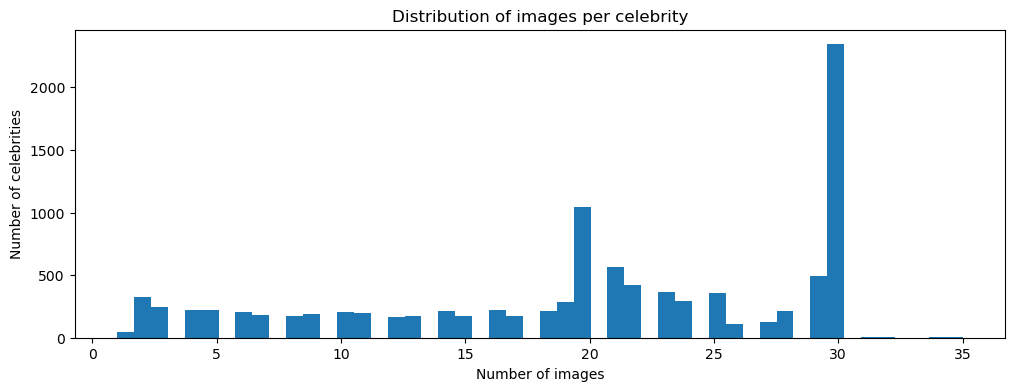

In [88]:
# Cell 1: Count images per celebrity
import pandas as pd

# Load the identity file
identity_file = "/Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt"
id_map = pd.read_csv(identity_file, sep=" ", header=None, names=["image", "identity"])

# Count number of images per celebrity
counts = id_map["identity"].value_counts().sort_index()

# Display first 10 celebrities
print("Number of images per celebrity (first 10 IDs):")
print(counts.head(10))

# Total number of unique celebrities
print(f"\nTotal unique celebrities: {id_map['identity'].nunique()}")

# Optional: Plot histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.hist(counts.values, bins=50)
plt.title("Distribution of images per celebrity")
plt.xlabel("Number of images")
plt.ylabel("Number of celebrities")
plt.show()
